<a href="https://colab.research.google.com/github/jainpalak1406-cpu/Design-and-Analysis-of-Algorithms-Lab/blob/main/DAA6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original: [4, 2, 2, 8, 3, 3, 1]
Sorted: [1, 2, 2, 3, 3, 4, 8]


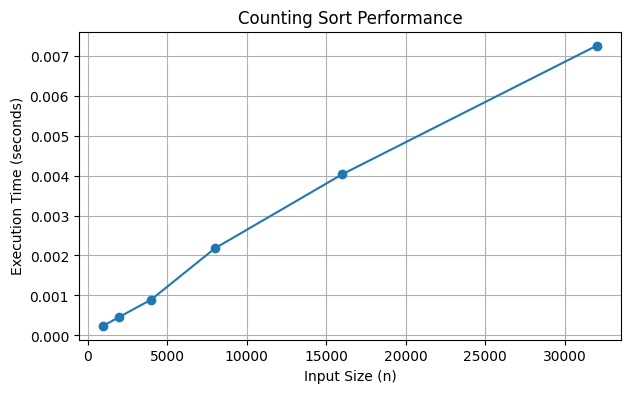

In [ ]:
#Linear-Time Sorting
#Counting sort
import random
import time
import matplotlib.pyplot as plt


def counting_sort(arr):

    if len(arr) == 0:
        return arr

    maximum = max(arr)
    minimum = min(arr)

    size = maximum - minimum + 1

    count = [0] * size


    for num in arr:
        count[num - minimum] += 1

    result = []

    for i in range(size):

        for j in range(count[i]):
            result.append(i + minimum)

    return result



arr = [4, 2, 2, 8, 3, 3, 1]

print("Original:", arr)
print("Sorted:", counting_sort(arr))


sizes = [1000, 2000, 4000, 8000, 16000, 32000]
times = []

for n in sizes:


    arr = [random.randint(0, 100) for _ in range(n)]

    start = time.perf_counter()
    counting_sort(arr)
    end = time.perf_counter()

    times.append(end - start)


plt.figure(figsize=(7, 4))
plt.plot(sizes, times, marker='o')
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Counting Sort Performance")
plt.grid(True)
plt.show()

Original: [0.42, 0.32, 0.23, 0.52, 0.25, 0.47, 0.51]
Sorted: [0.23, 0.25, 0.32, 0.42, 0.47, 0.51, 0.52]


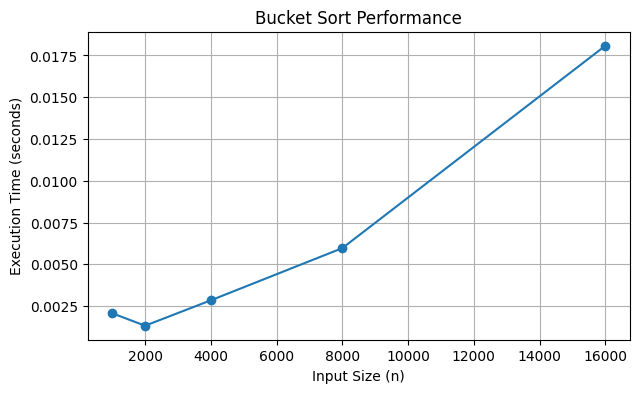

In [ ]:
#Bucket sort
import random
import time
import matplotlib.pyplot as plt


def bucket_sort(arr):

    n = len(arr)

    buckets = [[] for _ in range(n)]


    for num in arr:

        index = int(num * n)

        if index == n:
            index = n - 1

        buckets[index].append(num)

    for bucket in buckets:
        bucket.sort()


    result = []

    for bucket in buckets:
        for num in bucket:
            result.append(num)

    return result



arr = [0.42, 0.32, 0.23, 0.52, 0.25, 0.47, 0.51]

print("Original:", arr)
print("Sorted:", bucket_sort(arr))



sizes = [1000, 2000, 4000, 8000, 16000]
times = []

for n in sizes:

    arr = [random.random() for _ in range(n)]

    start = time.perf_counter()
    bucket_sort(arr)
    end = time.perf_counter()

    times.append(end - start)


plt.figure(figsize=(7, 4))
plt.plot(sizes, times, marker='o')
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Bucket Sort Performance")
plt.grid(True)
plt.show()

Number of subarrays: 7


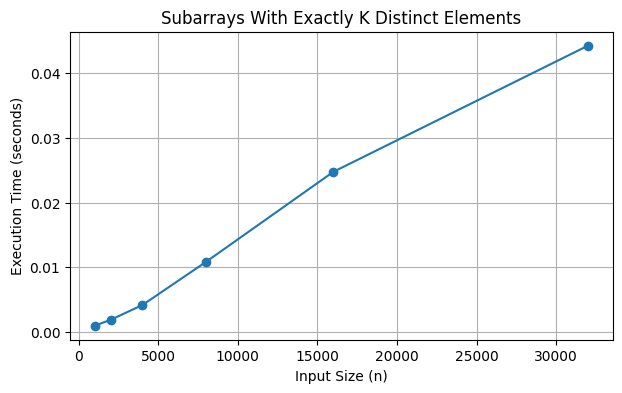

In [ ]:
#Count subarrays with exactly k distinct elements
import random
import time
import matplotlib.pyplot as plt


def at_most_k(arr, k):

    if k == 0:
        return 0

    count = {}
    left = 0
    result = 0

    for right in range(len(arr)):

        count[arr[right]] = count.get(arr[right], 0) + 1

        while len(count) > k:

            count[arr[left]] -= 1

            if count[arr[left]] == 0:
                del count[arr[left]]

            left += 1

        result += right - left + 1

    return result


def exactly_k_distinct(arr, k):

    return (
        at_most_k(arr, k)
        - at_most_k(arr, k - 1)
    )


arr = [1, 2, 1, 2, 3]

k = 2

print(
    "Number of subarrays:",
    exactly_k_distinct(arr, k)
)


sizes = [1000, 2000, 4000, 8000, 16000, 32000]
times = []

for n in sizes:

    arr = [random.randint(1, 20) for _ in range(n)]

    start = time.perf_counter()
    exactly_k_distinct(arr, 5)
    end = time.perf_counter()

    times.append(end - start)


plt.figure(figsize=(7, 4))
plt.plot(sizes, times, marker='o')
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Subarrays With Exactly K Distinct Elements")
plt.grid(True)
plt.show()

Original array: [10, 20, 7]
Minimum sum: 17


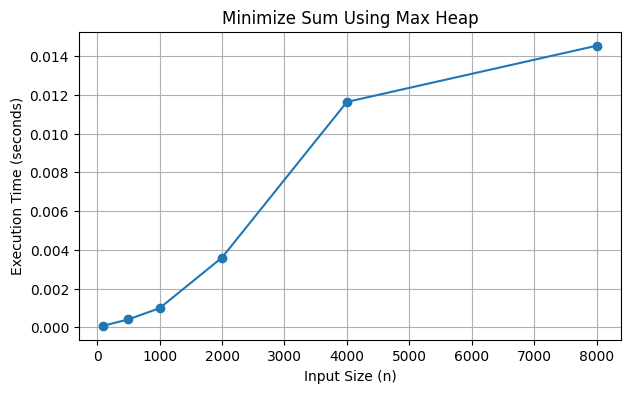

In [ ]:
#Minimize sum after k operations
import heapq
import random
import time
import matplotlib.pyplot as plt


def minimize_sum(arr, k):


    heap = []

    for num in arr:
        heapq.heappush(heap, -num)

    for _ in range(k):

        largest = -heapq.heappop(heap)

        new_value = (largest + 1) // 2

        heapq.heappush(heap, -new_value)

    total = 0

    while heap:
        total += -heapq.heappop(heap)

    return total



arr = [10, 20, 7]

k = 3

print("Original array:", arr)
print("Minimum sum:", minimize_sum(arr.copy(), k))



sizes = [100, 500, 1000, 2000, 4000, 8000]
times = []

for n in sizes:

    arr = [random.randint(1, 10000) for _ in range(n)]


    operations = n

    start = time.perf_counter()
    minimize_sum(arr, operations)
    end = time.perf_counter()

    times.append(end - start)


plt.figure(figsize=(7, 4))
plt.plot(sizes, times, marker='o')
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Minimize Sum Using Max Heap")
plt.grid(True)
plt.show()